# Preprocessing Heart Disease Dataset

This notebook contains the preprocessing steps for the Heart Disease dataset, including:

1. Load Libraries
2. Calling Dataset & Data Structure
3. Checking Dataset (Missing Value, Zero Value, & Duplicate Value)
4. Correlation Plot Original Features
5. Imputation of Zero Values
6. Encoding Categorical Features
7. Scaling Numeric Features
8. Save Processed Data & Artifacts

## 1. Load Libraries

In [30]:
# Load Libraries
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib



## 2. Calling Dataset & Data Structure

In [31]:
# Calling Dataset
df: pd.DataFrame = pd.read_csv("Data/heart.csv")
print(df.head())

# Data Structure
print("\n" + "="*50)
print("Data Structure and Feat. Type")
print("="*50)
print(f"\nDimension dataset: {df.shape}")
print("\nData Structure:")
print(df.info())
print("\nFeature Type:")
print(df.dtypes)
print("\nStatistics Desc.:")
print(df.describe())
print("\nUnique values per feat.:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Data Structure and Feat. Type

Dimension dataset: (918, 12)

Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non

## 3. Checking Dataset (Missing Value, Zero Value, & Duplicate Value)

In [32]:
# Checking Dataset (Missing Value, Zero Value, & Duplicate Value)
print(f"Duplicate rows: {df.duplicated().sum()}")

print("Missing values per column:\n", df.isna().sum())

num_cols = df.select_dtypes(include="number").columns
table_zeros = (df[num_cols] == 0).sum()
print("\nZero counts in numeric columns:\n", table_zeros)

Duplicate rows: 0
Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero counts in numeric columns:
 Age               0
RestingBP         1
Cholesterol     172
FastingBS       704
MaxHR             0
Oldpeak         368
HeartDisease    410
dtype: int64


## 4. Correlation Plot Original Features


Creating correlation plot for original numeric features...


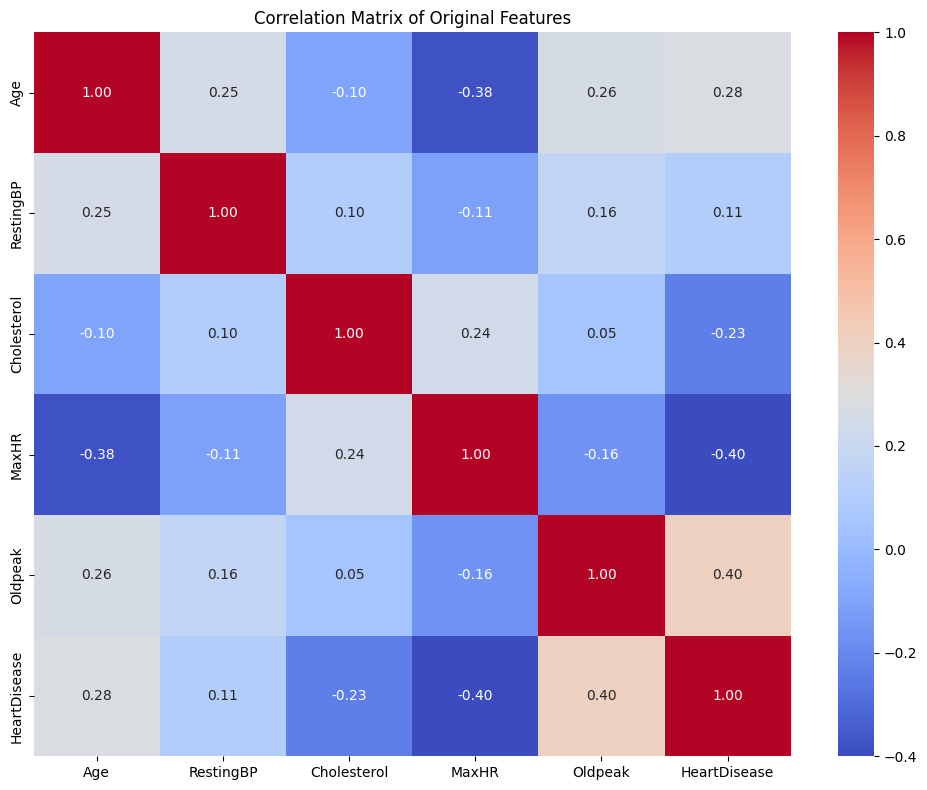

Saved: outputs/original_correlation.png


In [33]:
# Correlation plot for feature engineering before preprocessing
os.makedirs('outputs', exist_ok=True)
print(f"\nCreating correlation plot for original numeric features...")
correlation_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']
corr_matrix = df[correlation_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix of Original Features')
fig.tight_layout()
fig.savefig('outputs/original_correlation.png')
plt.show()
print("Saved: outputs/original_correlation.png")

## 5. Imputation of Zero Values

In [ ]:
# Imputation
print(f"\n" + "="*50)
print("IMPUTATION ZERO VALUES")
print("="*50)
print(f"\nOriginal dataset shape: {df.shape}")

cholesterol_median = df[df['Cholesterol'] != 0]['Cholesterol'].median()
resting_bp_median = df[df['RestingBP'] != 0]['RestingBP'].median()

print(f"\nZero values before imputation:")
print(f"  Cholesterol: {(df['Cholesterol'] == 0).sum()} nol values")
print(f"  RestingBP: {(df['RestingBP'] == 0).sum()} nol values")
print(f"  Oldpeak: {(df['Oldpeak'] == 0).sum()} nol values")

df_cleaned = df.copy()
df_cleaned.loc[df_cleaned['Cholesterol'] == 0, 'Cholesterol'] = cholesterol_median
df_cleaned.loc[df_cleaned['RestingBP'] == 0, 'RestingBP'] = resting_bp_median

print(f"\nMedian values:")
print(f"  Cholesterol median: {cholesterol_median}")
print(f"  RestingBP median: {resting_bp_median}")
print(f"\nCleaned dataset shape: {df_cleaned.shape}")
print(f"\nZero values after imputation:")
print(f"  Cholesterol: {(df_cleaned['Cholesterol'] == 0).sum()} nol values")
print(f"  RestingBP: {(df_cleaned['RestingBP'] == 0).sum()} nol values")
print(f"  Oldpeak: {(df_cleaned['Oldpeak'] == 0).sum()} nol values")


IMPUTASI NILAI NOL

Original dataset shape: (918, 12)

Nilai nol sebelum imputasi:
  Cholesterol: 172 nol values
  RestingBP: 1 nol values
  Oldpeak: 368 nol values

Median values:
  Cholesterol median: 237.0
  RestingBP median: 130.0

Cleaned dataset shape: (918, 12)

Nilai nol setelah imputasi:
  Cholesterol: 0 nol values
  RestingBP: 0 nol values
  Oldpeak: 368 nol values


## 6. Encoding Categorical Features

In [ ]:
# ENCODING CATEGORICAL FEATURES
print(f"\n" + "="*50)
print("ENCODING CATEGORICAL FEATURES")
print("="*50)

ml_df = df_cleaned.copy()

# Identificate Categorical Feat.
categorical_cols = ml_df.select_dtypes(include=['object']).columns.tolist()
print(f"\nFeat. categorical: {categorical_cols}")

# Encoding (Label Encoding & One-Hot Encoding)
binary_cols = []
multiclass_cols = []

for col in categorical_cols:
    n_unique = ml_df[col].nunique()
    print(f"  {col}: {n_unique} Category")
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multiclass_cols.append(col)

print(f"\nFeat. binary (label encoding): {binary_cols}")
print(f"Feat. multiclass (one-hot encoding): {multiclass_cols}")

encoders_dict = {}

# Label Encoding
if binary_cols:
    print(f"\nDoing label encoding at: {binary_cols}")
    encoders_dict['label_encoders'] = {}
    for col in binary_cols:
        le = LabelEncoder()
        ml_df[col] = le.fit_transform(ml_df[col])
        encoders_dict['label_encoders'][col] = le
        print(f"  {col}: {le.classes_} -> {list(range(len(le.classes_)))}")

# One-Hot Encoding
if multiclass_cols:
    print(f"\nDoing one-hot encoding at: {multiclass_cols}")
    ml_df_before_ohe = ml_df.copy()
    ml_df = pd.get_dummies(ml_df, columns=multiclass_cols, drop_first=False)
    encoders_dict['onehot_encoders'] = {
        'columns': multiclass_cols,
        'encoded_columns': [col for col in ml_df.columns if col not in ml_df_before_ohe.columns]
    }
    print(f"\nFeat. after one-hot encoding:")
    print(ml_df.columns.tolist())
else:
    print(f"\nTheres no feat. with >2 category for one-hot encoding")
    encoders_dict['onehot_encoders'] = None

print(f"\nFinal dataset shape: {ml_df.shape}")
print(f"\nFinal columns:")
print(ml_df.columns.tolist())
print(f"\nData types:")
print(ml_df.dtypes)


ENCODING CATEGORICAL FEATURES

Feat. categorical: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
  Sex: 2 Category
  ChestPainType: 4 Category
  RestingECG: 3 Category
  ExerciseAngina: 2 Category
  ST_Slope: 3 Category

Feat. binary (label encoding): ['Sex', 'ExerciseAngina']
Feat. multiclass (one-hot encoding): ['ChestPainType', 'RestingECG', 'ST_Slope']

Doing label encoding at: ['Sex', 'ExerciseAngina']
  Sex: ['F' 'M'] -> [0, 1]
  ExerciseAngina: ['N' 'Y'] -> [0, 1]

Doing one-hot encoding at: ['ChestPainType', 'RestingECG', 'ST_Slope']

Feat. after one-hot encoding:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Final dataset shape: (918, 19)

Final columns:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingB

## 7. Scaling Numeric Features

In [ ]:
# Scale numeric features for modeling
print(f"\n" + "="*50)
print("SCALING NUMERIC FEATURES")
print("="*50)

scale_cols = ['Age', 'RestingBP', 'Cholesterol', 'Oldpeak', 'MaxHR']
scaler = StandardScaler()
ml_df[scale_cols] = scaler.fit_transform(ml_df[scale_cols])
print(f"Scaled columns: {scale_cols}")
print(ml_df[scale_cols].describe())


SCALING NUMERIC FEATURES
Scaled columns: ['Age', 'RestingBP', 'Cholesterol', 'Oldpeak']
                Age     RestingBP   Cholesterol       Oldpeak
count  9.180000e+02  9.180000e+02  9.180000e+02  9.180000e+02
mean  -1.083616e-16  1.760877e-16  2.399436e-16  1.238419e-16
std    1.000545e+00  1.000545e+00  1.000545e+00  1.000545e+00
min   -2.706015e+00 -2.921979e+00 -2.964180e+00 -3.271482e+00
25%   -6.906294e-01 -6.973248e-01 -5.471911e-01 -8.324324e-01
50%    5.188098e-02 -1.411613e-01 -1.162551e-01 -2.695748e-01
75%    6.883185e-01  4.150021e-01  4.458352e-01  5.747115e-01
max    2.491558e+00  3.751983e+00  6.741247e+00  4.983762e+00


## 8. Save Processed Data & Artifacts

In [39]:
# Save processed data (final result of all preprocessing steps)
ml_df.to_csv('Data/heart_cleaned.csv', index=False)
print(f"\nSaved: Data/heart_cleaned.csv")

# Save scaler and training columns
joblib.dump(scaler, 'outputs/scaler.pkl')
print(f"\nScaler saved to: outputs/scaler.pkl")
train_columns = ml_df.drop(columns=['HeartDisease']).columns.tolist()
joblib.dump(train_columns, 'outputs/train_columns.pkl')
print(f"Train columns saved to: outputs/train_columns.pkl")

# Save encoder objects
joblib.dump(encoders_dict, 'outputs/encoders.pkl')
print(f"\nEncoder objects saved to: outputs/encoders.pkl")
print(f"\nEncoder dictionary structure:")
print(f"  - label_encoders: {list(encoders_dict.get('label_encoders', {}).keys())}")
if encoders_dict.get('onehot_encoders'):
    print(f"  - onehot_encoders:")
    print(f"      - columns: {encoders_dict['onehot_encoders']['columns']}")
    print(f"      - encoded_columns: {len(encoders_dict['onehot_encoders']['encoded_columns'])} columns")


Saved: Data/heart_cleaned.csv

Scaler saved to: outputs/scaler.pkl
Train columns saved to: outputs/train_columns.pkl

Encoder objects saved to: outputs/encoders.pkl

Encoder dictionary structure:
  - label_encoders: ['Sex', 'ExerciseAngina']
  - onehot_encoders:
      - columns: ['ChestPainType', 'RestingECG', 'ST_Slope']
      - encoded_columns: 10 columns


## 9. Conclusion

- The cleaned dataset (`Data/heart_cleaned.csv`) has **918 rows × 22 features**
  (after one-hot encoding) with no missing or duplicate values.
- Zero values in `Cholesterol` and `RestingBP` were replaced with the median.
- Categorical features: label encoding for binary columns, one-hot encoding
  for multiclass columns (encoders saved in `outputs/encoders.pkl`).
- Numeric features scaled with `StandardScaler` (saved in `outputs/scaler.pkl`).
- These artifacts are reused by the modeling notebook and the deployed API.